In [ ]:
import numpy as np
import matplotlib.pyplot as plt
#from matplotlib.colors import ListedColormap
import pandas as pd
import seaborn as sns

#from sklearn import tree

#from sklearn.impute import SimpleImputer
#from sklearn.compose import ColumnTransformer
#from sklearn.preprocessing import OneHotEncoder
#from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

#from sklearn.linear_model import LinearRegression
#from sklearn.tree import DecisionTreeRegressor
#from sklearn.ensemble import RandomForestRegressor

#from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

#from sklearn.model_selection import cross_val_score
#from sklearn.model_selection import GridSearchCV

#from sklearn.metrics import r2_score
#from sklearn.metrics import mean_absolute_error

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


In [ ]:
titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
print(titanic.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None


In [ ]:
titanic.drop('deck',  axis=1, inplace=True)

In [ ]:
dataset2 = titanic.dropna(axis=0) #retira as linhas com NaN

In [ ]:
features = ['pclass', 'age', 'sibsp', 'fare','adult_male']

X = dataset2[features].values
y = dataset2.survived
y

,survived
0,0
1,1
2,1
3,1
4,0
...,...
885,0
886,0
887,1
889,1


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

X = np.array(ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [-1])], remainder='passthrough').fit_transform(X))
X

array([[0.0, 1.0, 3, 22.0, 1, 7.25],
       [1.0, 0.0, 1, 38.0, 1, 71.2833],
       [1.0, 0.0, 3, 26.0, 0, 7.925],
       ...,
       [1.0, 0.0, 1, 19.0, 0, 30.0],
       [0.0, 1.0, 1, 26.0, 0, 30.0],
       [0.0, 1.0, 3, 32.0, 0, 7.75]], dtype=object)

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [ ]:

classifier_rf = RandomForestClassifier(max_depth= 5, n_estimators = 15, random_state = 0)
classifier_rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, n_estimators=15, random_state=0)

In [ ]:
y_pred_rf = classifier_rf.predict(X_test)

In [ ]:
accuracy_score(y_test, y_pred_rf)

0.8321678321678322

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)
print(cm)

[[74  8]
 [16 45]]


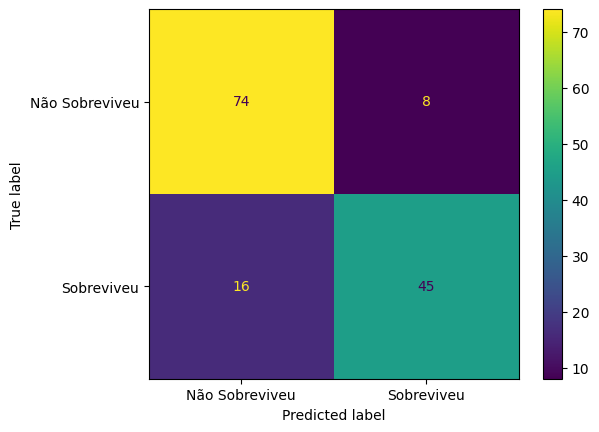

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels = ['Não Sobreviveu', 'Sobreviveu'])
disp.plot();

In [ ]:
#Totais reais
y_test.value_counts()

,count
survived,
0,82
1,61


In [ ]:
#Totais previsto
y_pred_dt = pd.DataFrame(y_pred_rf, columns=["survived"])
y_pred_dt.value_counts()

,count
survived,
0,90
1,53


## Métricas

Medição | Descrição | fórmula
- | - | -
Acurácia | Trata-se da métrica mais simples que permite mensurar o percentual de acertos,<br> isto é, a quantidade de previsões corretas dentro do total de previsões possíveis.<br>Responde à pergunta: dentre todas as previsões realizadas, quantas o modelo acertou? | (VP+VN) / N
Sensibilidade (recall) | Trata-se da métrica que permite avaliar a capacidade do classificador<br>de detectar com sucesso resultados positivos (também chamado de revocação ou recall). <br>Responde à pergunta: dentre os valores realmente positivos, quantos o modelo acertou<br>(previu corretamente como positivo)? | VP / (VP+FN)
Especificidade (Specificity) | Trata-se da métrica que permite avaliar a capacidade do classificador de<br>detectar com sucesso resultados negativos. Responde à pergunta: dentre os valores<br>realmente negativos quantos o modelo acerto (previu corretamente como negativo)? | VN/(FP+VN)
Precisão | Trata-se da métrica que permite mensurar a proporção de previsões positivas corretas<br>sobre a soma de todos os valores positivos. Responde à pergunta: dentre os valores<br>previstos como positivos, quantos o modelo acertou (previu corretamente como positivo)? | VP/(VP+FP)
F1-score | Trata-se da média harmônica calculada com base na precisão e na sensibilidade, logo é uma<br>medida derivada dessas outras medidas. Essa medida tenta condensar em uma única medida<br>um pouco da precisão e um pouco da sensibilidade. | 2 ∗ ((PRECISÃO ∗ RECALL)/(PRECISÃO + RECALL))

### Qual é a necessidade desse tanto de medidas diferentes?

Dependendo do contexto, o desempenho pode ser medido de maneira diferente para refletir melhor a efetividade da medição. Em alguns casos, ter falsos-negativos não é tão relevante; em outros casos, ter falsos-positivos pode ser muito relevante. Por isso existem tantas formas diferentes de medir o desempenho.


A precisão pode ser utilizada em situações em que falsos-positivos são mais prejudiciais que os falsos-negativos. Por exemplo: ao classificar ações da bolsa de valores como boas ou ruins, um falso-positivo pode fazer uma pessoa investir em uma ação ruim e ter prejuízos; já um falso-negativo pode fazer uma pessoa não investir em uma ação boa e deixar de ter lucros, mas ela não terá prejuízos, logo é menos prejudicial.

Já o recall pode ser utilizado em situações em que falsos-negativos são mais prejudiciais que os falsos-positivos. Por exemplo: ao classificar uma pessoa com vacinado ou não-vacinado, um falso-positivo
pode fazer uma pessoa saudável não pegar um avião com outras pessoas; já um falso-negativo pode fazer uma pessoa infectada pegar um avião com outras pessoas e infectá-las com seu vírus.

Entenderam a importância de medidas diferentes?

#### Acurácia

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred_rf)

0.8321678321678322

#### Sensibilidade

In [ ]:
from sklearn.metrics import recall_score

recall_score(y_test, y_pred_rf)

#Acertei 45 sobreviventes dentre 61 (45+16) que realmente sobreviveram

0.7377049180327869

#### Especificidade

In [ ]:
from sklearn.metrics import recall_score

recall_score(y_test, y_pred_rf, pos_label=0)

#Acertei 74 que não sobreviveram dentre 82 (74+8) que realmente não sobreviveram

0.9024390243902439

In [ ]:
vn, fp, fn, vp = confusion_matrix(y_test, y_pred_rf).ravel()
especificidade = vn / (vn+fp)
especificidade
#Acertei 74 que não sobreviveram dentre 82 (74+8) que realmente não sobreviveram


0.9024390243902439

#### Precisão



In [ ]:
from sklearn.metrics import precision_score

precision_score(y_test, y_pred_rf)
#Acertei 45 sobreviventes dentro de 53 sobreviventes que inferi (45+8)

0.8490566037735849

In [ ]:
from sklearn.metrics import precision_score

precision_score(y_test, y_pred_rf, pos_label=0)
#Acertei 74 não sobreviventes dentro de 90 não sobreviventes que inferi (74+16)

0.8222222222222222

#### F1-Score



In [ ]:
from sklearn.metrics import f1_score

f1_score(y_test, y_pred_rf)
#Relação nos sobreviventes

0.7894736842105263

In [ ]:
from sklearn.metrics import f1_score

f1_score(y_test, y_pred_rf, pos_label=0)
#Relação nos não sobreviventes

0.8604651162790697

#### Relatório de classificação



In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rf, target_names=['Não Sobreviveu', 'Sobreviveu']))

                precision    recall  f1-score   support

Não Sobreviveu       0.82      0.90      0.86        82
    Sobreviveu       0.85      0.74      0.79        61

      accuracy                           0.83       143
     macro avg       0.84      0.82      0.82       143
  weighted avg       0.83      0.83      0.83       143

